In [ ]:
import functions as f
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import pandas as pd
from lmfit import Model, Parameters
from scipy import optimize, constant
plt.style.use(['science','no-latex','ieee'])

NameError: name 'logging' is not defined

findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


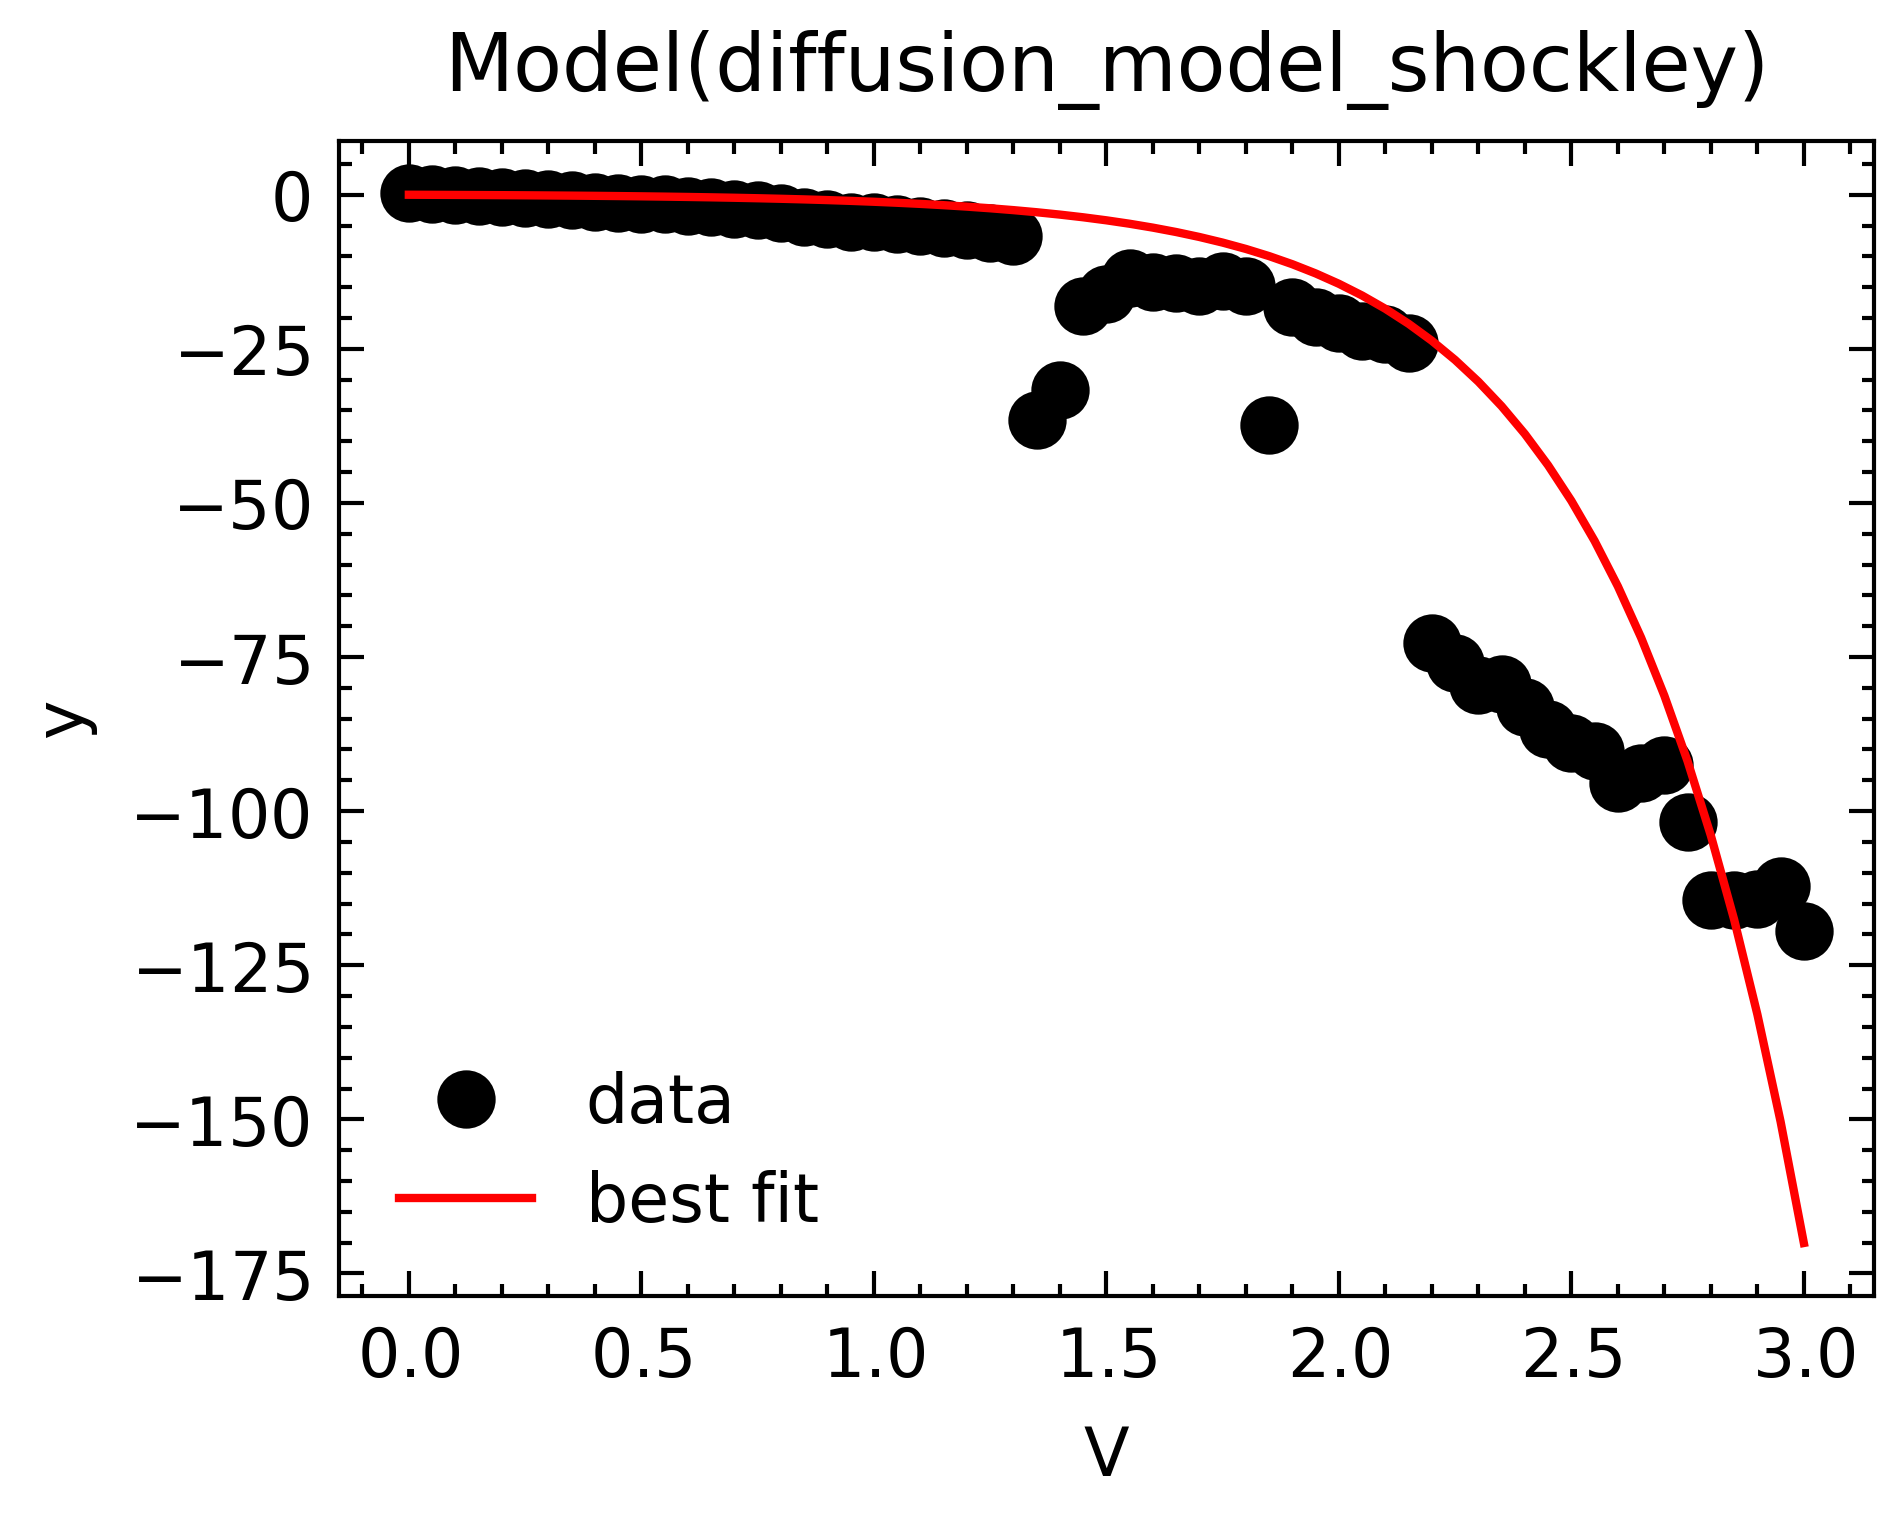

In [95]:
e, kB, phi_0, d, T, alpha, m, n_0, tau_e, D_e =  f.parameters_value_from_reference()
file  = "data/Data Efisiensi DSSC Erma.xlsx"
sheet = np.arange(0, 5, 1) 

dssc_model = Model(f.diffusion_model_shockley)
params = Parameters()

params.add('m',     value=4.5,   vary=True, min=1.0,  max=20.0)
params.add('n_0',   value=1e14,  vary=True, min=1e12, max=1e17)
params.add('tau_e', value=0.01,  vary=True, min=1e-4, max=0.5)
params.add('D_e',   value=1e-4,  vary=True, min=1e-6, max=1e-2)


data =  pd.read_excel(file, sheet_name=0)
d = 0.003 # cm (estimasi 30 \micro m)
#phi = 100 #mW/cm2
V, J = data.iloc[:,0], data.iloc[:,1]
result = dssc_model.fit(J, params, V=V, method="leqstsq")
result.plot_fit()
result